In [52]:
import numpy as np
import pandas as pd
import time

In [53]:
df=pd.read_csv('/content/Social_Network_Ads.csv')
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [61]:
x,y=df.iloc[:,0:-1],df.iloc[:,-1]
x.shape, y.shape

((400, 2), (400,))

In [62]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=2)
xtrain.shape, xtest.shape, ytrain.shape, ytest.shape

((320, 2), (80, 2), (320,), (80,))

In [63]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
xtrains=sc.fit_transform(xtrain)
xtests=sc.transform(xtest)

In [64]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [65]:
model=Sequential()
model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [66]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
s=time.time()
history=model.fit(xtrains,ytrain,epochs=500,batch_size=320) # BATCH_GD as batch_size=xtrain.shape[0]
print(time.time()-s)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3156 - loss: 0.7467
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.3187 - loss: 0.7305
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.3500 - loss: 0.7191
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.3562 - loss: 0.7099
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.3688 - loss: 0.7017
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.3875 - loss: 0.6944
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.4000 - loss: 0.6878
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.4344 - loss: 0.6815
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.5000 - loss: 0.6757
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.5531 - loss: 0.6701
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.5969 - loss: 0.6648
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.6

From the above execution we can observe Batch GD takes less time to execute, but its accuracy is 67.5% and not much reduction in Loss.

In [59]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
s=time.time()
history=model.fit(xtrains,ytrain,epochs=500,batch_size=1) # STOCHASTIC_GD as batch_size=1
print(time.time()-s)

Epoch 1/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6812 - loss: 0.6444
Epoch 2/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7844 - loss: 0.4689
Epoch 3/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8281 - loss: 0.3770
Epoch 4/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8406 - loss: 0.3318
Epoch 5/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8469 - loss: 0.3108
Epoch 6/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8719 - loss: 0.3010
Epoch 7/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8750 - loss: 0.2942
Epoch 8/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8781 - loss: 0.2913
Epoch 9/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8813 - loss: 0.2860
Epoch 10/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8844 - loss: 0.2798
Epoch 11/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8844 - loss: 0.2762
Epoch 12/500
320/320 ━━━━━━━━━━━━━━━━━━━━

1. STOCHASTIC GD takes more time duration to execute as it needed to perform 320 weights and bias updates every epoch for 10 epochs.
2. But we can observe the accuracy was high to start with as compared with BATCH GD and improved significantly to 90%.
3. Also Loss had seen a significant reduction from 0.6207 to 0.2581.

As per #2 and #3 we can understand the SGD converges significantly faster compared to Batch GD.

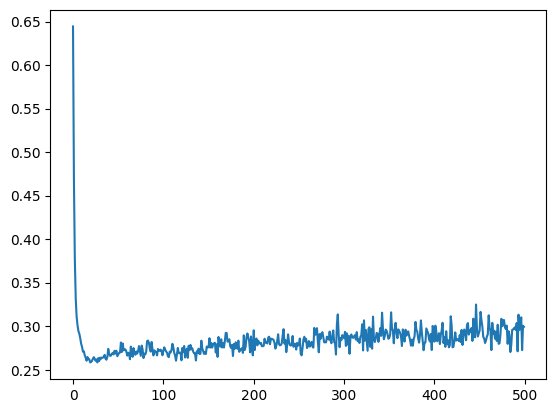

In [60]:
from matplotlib import pyplot as plt
plt.plot(history.history['loss'])
plt.show();

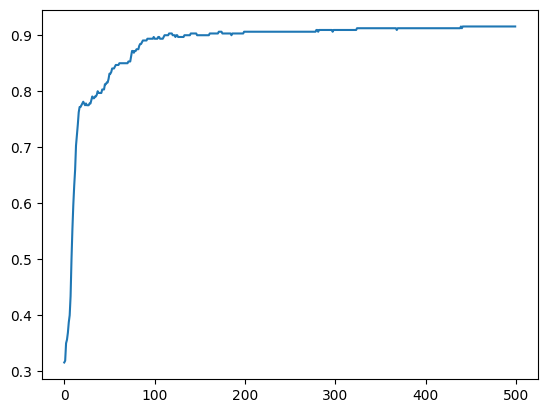

In [67]:
from matplotlib import pyplot as plt
plt.plot(history.history['accuracy'])
plt.show();